## Task 17: Assignment


Q1. Load the Heart Disease dataset using pandas and display the first 10 rows.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the heart disease dataset
df = pd.read_csv("heart.csv")

# Display the first 10 rows
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS
0,40,M,ATA,140,289,0
1,49,F,NAP,160,180,0
2,37,M,ATA,130,283,0
3,48,F,ASY,138,214,0
4,54,M,NAP,150,195,0
5,39,M,NAP,120,339,0
6,45,F,ATA,130,237,0
7,54,M,ATA,110,208,0
8,37,M,ASY,140,207,0
9,48,F,ATA,120,284,0


Q2. Check for missing values in the dataset. Show the count of null values for
each column.


In [3]:
# Check for null/missing values and show the count for each column
df.isnull().sum()

Age              0
Sex              0
ChestPainType    0
RestingBP        0
Cholesterol      0
FastingBS        0
dtype: int64

Q3. Check for duplicate rows in the dataset. If any duplicates are found, remove
them and print the new shape of the dataset.

In [4]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# Remove duplicates if found
if duplicate_count > 0:
    df = df.drop_duplicates()

# Print the new shape of the dataset
print("New shape of the dataset:", df.shape)

Number of duplicate rows: 166
New shape of the dataset: (1671, 6)


Q4. Identify unrealistic/invalid values:

Count how many rows have Cholesterol = 0.

Count how many rows have RestingBP = 0.

Print both counts.


In [5]:
# Count unrealistic/invalid values  
zero_cholesterol = (df['Cholesterol'] == 0).sum()
zero_restingbp = (df['RestingBP'] == 0).sum()

# Print both counts
print("Rows with Cholesterol = 0:", zero_cholesterol)
print("Rows with RestingBP = 0:", zero_restingbp)

Rows with Cholesterol = 0: 0
Rows with RestingBP = 0: 0


Q5. Clean the invalid values:

Replace Cholesterol = 0 with the mean cholesterol value (excluding zeros).

Replace RestingBP = 0 with the mean resting blood pressure value (excluding zeros).

Round both columns to 2 decimal places.

Print the statistical summary (describe()) of these two columns before and after
cleaning.



In [6]:
# Force the columns to be numeric, turning text errors into clear blank fields
df["Cholesterol"] = pd.to_numeric(df["Cholesterol"], errors="coerce")
df["RestingBP"] = pd.to_numeric(df["RestingBP"], errors="coerce")

# Drop any row that couldn't be converted to a proper number
df = df.dropna(subset=["Cholesterol", "RestingBP"])

# Print statistical summary BEFORE cleaning
print("Summary BEFORE Cleaning ")
print(df[["Cholesterol", "RestingBP"]].describe())

# Calculate mean values excluding the zero values
mean_chol = df[df["Cholesterol"] != 0]["Cholesterol"].mean()
mean_rbp = df[df["RestingBP"] != 0]["RestingBP"].mean()

# Replace 0 with the corresponding mean values
df["Cholesterol"] = df["Cholesterol"].replace(0, mean_chol)
df["RestingBP"] = df["RestingBP"].replace(0, mean_rbp)

# Round both columns to 2 decimal places
df["Cholesterol"] = df["Cholesterol"].round(2)
df["RestingBP"] = df["RestingBP"].round(2)

# Print statistical summary AFTER cleaning
print("\n Summary AFTER Cleaning ")
print(df[["Cholesterol", "RestingBP"]].describe())

Summary BEFORE Cleaning 
       Cholesterol   RestingBP
count   910.000000  910.000000
mean    199.802198  132.423077
std     108.842608   18.548189
min       0.000000    0.000000
25%     175.000000  120.000000
50%     223.000000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000

 Summary AFTER Cleaning 
       Cholesterol   RestingBP
count   910.000000  910.000000
mean    244.710516  132.568758
std      53.516710   18.020064
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.710000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000


Q6. Create a function to plot histograms for the following numerical columns: 
1.	Age 
2.	RestingBP 
3.	Cholesterol 
4.	MaxHR 

Plot all four histograms in one figure using subplots (2x2 layout).
 
Use this function to visualize the data after cleaning.


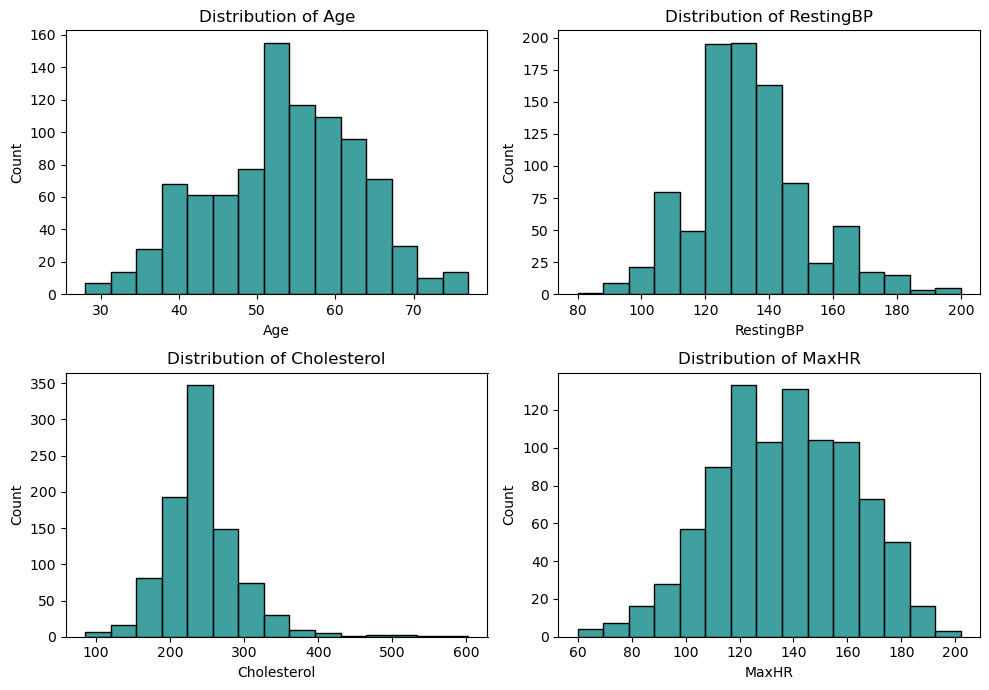

In [12]:
def display_all_histograms(dataframe):
    target_columns = ["Age", "RestingBP", "Cholesterol", "MaxHR"]

    plt.figure(figsize=(10, 7))

    for index, column_name in enumerate(target_columns, 1):
        plt.subplot(2, 2, index)
        sns.histplot(dataframe[column_name], bins=15, color="teal")
        plt.title(f"Distribution of {column_name}")

    plt.tight_layout()
    plt.show()


# Call the function directly using your existing clean dataframe
display_all_histograms(df)

Q7. Identify and print numerical columns and categorical columns separately.


In [13]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

# Print the separated lists
print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR']
Categorical Columns: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


Q8. Perform One-Hot Encoding on all categorical columns using pd.get_dummies().

Store the result in a new dataframe called df_encoded.

Print the shape and the first 5 rows of the encoded dataframe.


In [14]:
# Perform One-Hot Encoding on categorical columns
df_encoded = pd.get_dummies(df)

# Print the shape of the encoded dataframe
print("Shape of df_encoded:", df_encoded.shape)

# Display the first 5 rows
df_encoded.head(5)

Shape of df_encoded: (918, 75)


,Age,RestingBP,Cholesterol,MaxHR,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,...,Oldpeak_4.2,Oldpeak_4.4,Oldpeak_5,Oldpeak_5.6,Oldpeak_6.2,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,HeartDisease_0,HeartDisease_1
0,40,140.0,289.0,172,False,True,False,True,False,False,...,False,False,False,False,False,False,False,True,True,False
1,49,160.0,180.0,156,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
2,37,130.0,283.0,98,False,True,False,True,False,False,...,False,False,False,False,False,False,False,True,True,False
3,48,138.0,214.0,108,True,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,True
4,54,150.0,195.0,122,False,True,False,False,True,False,...,False,False,False,False,False,False,False,True,True,False


Q9. After cleaning and encoding:

Print the final shape of df_encoded.

Show the list of all column names in the final dataframe.


In [18]:
# Print the final shape of the encoded dataframe
print("Final Shape of df_encoded:", df_encoded.shape)

# Show the list of all column names in the final dataframe
print("\nAll Column Names:")
print(df_encoded.columns.tolist())

Final Shape of df_encoded: (918, 75)

All Column Names:
['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'FastingBS_0', 'FastingBS_1', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'Oldpeak_-0.1', 'Oldpeak_-0.5', 'Oldpeak_-0.7', 'Oldpeak_-0.8', 'Oldpeak_-0.9', 'Oldpeak_-1', 'Oldpeak_-1.1', 'Oldpeak_-1.5', 'Oldpeak_-2', 'Oldpeak_-2.6', 'Oldpeak_0', 'Oldpeak_0.1', 'Oldpeak_0.2', 'Oldpeak_0.3', 'Oldpeak_0.4', 'Oldpeak_0.5', 'Oldpeak_0.6', 'Oldpeak_0.7', 'Oldpeak_0.8', 'Oldpeak_0.9', 'Oldpeak_1', 'Oldpeak_1.1', 'Oldpeak_1.2', 'Oldpeak_1.3', 'Oldpeak_1.4', 'Oldpeak_1.5', 'Oldpeak_1.6', 'Oldpeak_1.7', 'Oldpeak_1.8', 'Oldpeak_1.9', 'Oldpeak_2', 'Oldpeak_2.1', 'Oldpeak_2.2', 'Oldpeak_2.3', 'Oldpeak_2.4', 'Oldpeak_2.5', 'Oldpeak_2.6', 'Oldpeak_2.8', 'Oldpeak_2.9', 'Oldpeak_3', 'Oldpeak_3.1', 'Oldpeak_3.2', 'Oldpeak_3.4', 'Oldpeak_3.5', 'Oldpeak_3.6',